In [1]:
import pandas as pd

In [2]:
# Load the json file
instances = pd.read_json(
    r"D:\FinalYearProject2Own\dataset\dataset\instances.jsonl",
    lines=True)


In [3]:
truth = pd.read_json(
    r"D:\FinalYearProject2Own\dataset\dataset\truth.jsonl",
    lines=True
)

In [4]:
# Merge two json file 
df = pd.merge(
    instances,
    truth,
    on="id"
)

print(df.shape)

(19538, 14)


In [5]:
print(df.columns)

Index(['postMedia', 'postText', 'id', 'targetCaptions', 'targetParagraphs',
       'targetTitle', 'postTimestamp', 'targetKeywords', 'targetDescription',
       'truthJudgments', 'truthMean', 'truthClass', 'truthMedian',
       'truthMode'],
      dtype='object')


In [6]:
df.sample(5)

,postMedia,postText,id,targetCaptions,targetParagraphs,targetTitle,postTimestamp,targetKeywords,targetDescription,truthJudgments,truthMean,truthClass,truthMedian,truthMode
12137,[media/photo_847682622645952515.jpg],"[New study finds ""staggering"" rise in mastecto...",847682625892306944,"[Bold and Breastless_00004306, Bold and Breast...","[(CNN)For many, the Fourth of July evokes jovi...",Study finds 'staggering' rise in mastectomies ...,Fri Mar 31 05:31:01 +0000 2017,"health, Study finds 'staggering' rise in maste...","Younger women with breast cancer in Nebraska, ...","[0.33333333330000003, 0.33333333330000003, 0.0...",0.266667,no-clickbait,0.333333,0.333333
13085,[media/photo_821289271680237569.jpg],[Donald Trump's inauguration poem call Barack ...,821289283931828224,[donald-trump.jpg],['With purpose and strength he came down from ...,Poem celebrating Donald Trump's inauguration d...,Tue Jan 17 09:33:18 +0000 2017,"Donald Trump, presidential inauguration, Ameri...",A poem has been written for Donald Trump's ina...,"[0.6666666666000001, 0.0, 0.33333333330000003,...",0.266667,no-clickbait,0.333333,0.333333
6727,[media/photo_834040199638372354.jpg],[Hermann Rorschach's famous inkblots are now h...,834040202188509184,[],"[Emmanuel Ocbazghi and Jessica Orwig, Feb. 21,...",Scientists are using Rorschach inkblots to hel...,Tue Feb 21 14:00:54 +0000 2017,,Building a bionic eye is even harder than you ...,"[0.33333333330000003, 0.0, 0.33333333330000003...",0.333333,no-clickbait,0.333333,0.333333
613,[media/photo_841222318508654593.jpg],"[All the previews, picks and bracket breakdown...",841222321486647296,[loading],"[Bracket Breakdowns, East Region: Villanova, t...","2017 NCAA Tournament: All the previews, picks ...",Mon Mar 13 09:40:05 +0000 2017,2017 ncaa tournament,Here's everything you need to know before you ...,"[0.0, 0.0, 0.0, 1.0, 0.33333333330000003]",0.266667,no-clickbait,0.000000,0.000000
12067,[media/photo_849670333552484352.jpg],[It looks like JPMorgan is building a robo adv...,849670336044032000,[],"[If you can’t beat ’em, join ’em., In the summ...",It Looks Like JPMorgan Is Building a Robo Adviser,Wed Apr 05 17:09:28 +0000 2017,"personal-finance,markets,technology,world","If you can’t beat ’em, join ’em.","[0.6666666666000001, 0.33333333330000003, 0.66...",0.533333,clickbait,0.666667,0.666667


In [7]:
headline_df_Mean = df[
    ["postText",
    "truthMean"
    ]
].copy()

In [8]:
# Converting post Text list to string
headline_df_Mean["headline"] = headline_df_Mean["postText"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

In [9]:
# Drop the postText because it is list and we converted those list to string
headline_df_Mean.drop(
    columns=["postText"],
    inplace=True
)

In [10]:
len(headline_df_Mean)

19538

In [11]:
# Removing Duplicates
headline_df_Mean.drop_duplicates(
    subset=["headline"],
    inplace=True
)

print("Remaining Samples:", len(headline_df_Mean))

Remaining Samples: 19082


In [12]:
# Assigning 3 different class according to the Truth Mean Value
def clickbait_level(value):
    if value <= 0.33:
        return "Low Clickbait"
    elif value <= 0.66:
        return "Moderate Clickbait"
    else:
        return "High Clickbait"

headline_df_Mean["Clickbait Category"] = headline_df_Mean["truthMean"].apply(clickbait_level)

In [13]:
# Drop Truth Mean
headline_df_Mean.drop(
    columns=["truthMean"],
    inplace=True
)

In [14]:
headline_df_Mean.sample(5)

,headline,Clickbait Category
3259,217 arrested after some D.C. protests on Inaug...,Low Clickbait
4893,"11-year-old Chicago shooting victim dies, todd...",Moderate Clickbait
5079,Long overdue.,High Clickbait
2780,PwC issues 'sincere apology' for Oscars best p...,Low Clickbait
8801,"Metallica's James Hetfield was ""livid"" over th...",Moderate Clickbait


In [15]:
import re
import string
import nltk


In [16]:
nltk.download('punkt')
nltk.download('punkt_tab')  

[nltk_data] Downloading package punkt to C:\Users\ANKON
[nltk_data]     BANERJEE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ANKON
[nltk_data]     BANERJEE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
from nltk.corpus import stopwords 

In [18]:
from nltk.stem.porter import PorterStemmer
import string



In [19]:
# Preprocess the text it includes --lowercasing,removing punctuations,removing html tags and urls (using regular Expressions)
# Convert the words to tokens and then after all cleaning  concate all tokens to make string
def preprocess_text(text):
    # Handle missing values
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Keep only words and numbers (removes punctuation)
    tokens = [word for word in tokens if word.isalnum()]

    # Join tokens back into a string
    return " ".join(tokens)

In [20]:
# Applying the preprocess function to clean the text
headline_df_Mean["Clean_headline"] = headline_df_Mean["headline"].apply(
    preprocess_text)


In [21]:
# Label encoding but here we are not using the scikit Learn Function
label_map = {
    "Low Clickbait": 0,
    "Moderate Clickbait": 1,
    "High Clickbait": 2
}

headline_df_Mean["Clickbait Category"] = headline_df_Mean["Clickbait Category"].map(label_map)

In [22]:
print(headline_df_Mean["Clickbait Category"].value_counts())

Clickbait Category
0    10682
1     5670
2     2730
Name: count, dtype: int64


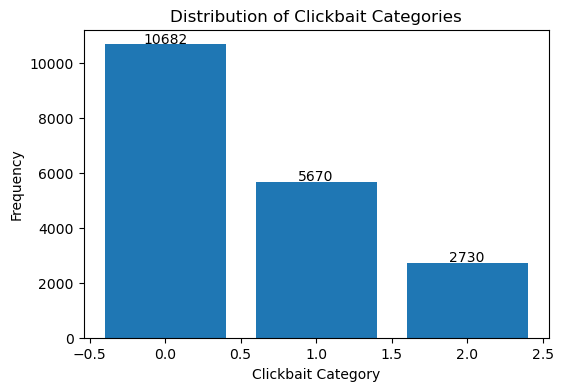

In [23]:
# Check how the texts are distributed in 3 different class
import matplotlib.pyplot as plt

# Count the number of samples in each class
class_counts = headline_df_Mean["Clickbait Category"].value_counts()

# Create bar plot
plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)

# Labels and title
plt.xlabel("Clickbait Category")
plt.ylabel("Frequency")
plt.title("Distribution of Clickbait Categories")

# Display the count on top of each bar
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 50, str(count), ha='center')

plt.show()

In [24]:
headline_df_Mean.drop(
    columns=["headline"],
    inplace=True
)

In [25]:
headline_df_Mean.head()

,Clickbait Category,Clean_headline
0,0,uk s response to modern slavery leaving victim...
1,2,this is good
2,1,the forgotten trump roast relive his brutal 20...
3,2,meet the happiest dog in the world
4,0,tokyo subway is shut down amid fears over an i...


In [26]:
from sklearn.model_selection import train_test_split

# Features and target
X = headline_df_Mean["Clean_headline"]
y = headline_df_Mean["Clickbait Category"]



In [27]:

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 30% -> 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Print sizes
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 13357
Validation: 2862
Testing: 2863


In [28]:
# The dataset is first divided into training (70%), validation (15%), and testing (15%) sets before applying TF-IDF to prevent data leakage.
#The TF-IDF vectorizer is fitted only on the training set, where it learns the vocabulary and calculates the Inverse Document Frequency (IDF) values.
#The fitted vectorizer is then used to transform the validation and test sets using the same vocabulary and IDF scores. This ensures that no
#information from the validation or test data influences feature extraction, resulting in an unbiased and reliable evaluation of the model.

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
     min_df=2,
    max_df=0.95
)  # lowercase=True, removing stopwords  are done automatically by this function

In [29]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfid=tfidf.transform(X_val)
X_test_tfidf=tfidf.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [31]:
# Logistic Regression
# C=10 (Less Regularized  default Value C=1)
lr = LogisticRegression(
    C=10,
    random_state=42,
    max_iter=1000,)

lr.fit(X_train_tfidf, y_train)



LogisticRegression(C=10, max_iter=1000, random_state=42)

In [32]:
# Multinomial Naive Bayes
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)



MultinomialNB(alpha=0.1)

In [33]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
svc = SVC(
    C=1.0,
    kernel='linear',   # Linear kernel works best for TF-IDF text data
    random_state=42
)

# Train the model
svc.fit(X_train_tfidf, y_train)


SVC(kernel='linear', random_state=42)

In [35]:
# storing the accuracy, precision,recall and f1 score of each model in a list
# Everything is calculated w.r.t the High Clickbait class(Class=2) As this class has the lowest no of input text
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
results=[]

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Support Vector Classifier":svc
}

for model_name, model in models.items():

    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[2],          # High Clickbait
        average=None
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (High)": precision[0],
        "Recall (High)": recall[0],
        "F1-Score (High)": f1[0]
    })

In [36]:
# Store that list into a Pandas Data Frame 
results_df = pd.DataFrame(results)

results_df
 #The Before Click model prioritizes precision while maintaining an acceptable level of recall. Since this model serves as an early warning
#system rather than the final decision-maker, it should warn users only when there is high confidence that a headline is High Clickbait. This helps
#reduce false warnings and prevents users from unnecessarily ignoring legitimate news articles. At the same time, recall should remain at a reasonable 
#level so that the model can still identify a meaningful number of High Clickbait headlines. Therefore, the model is selected based on a balanced 
#trade-off, giving higher importance to precision without allowing recall to become too low.

,Model,Accuracy,Precision (High),Recall (High),F1-Score (High)
0,Logistic Regression,0.609151,0.516340,0.386308,0.441958
1,Naive Bayes,0.623472,0.554585,0.310513,0.398119
2,Random Forest,0.638142,0.512111,0.361858,0.424069
3,Support Vector Classifier,0.640587,0.578261,0.325183,0.416275


In [37]:
# Again storing accuracy,precision,recall anf f1 score of each class in a list named result. But this time we have taken the values as
# Weighted Average
# Print Classification Report of each Model as well
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Support Vector Classifier":svc
}

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Store metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

    # Print Classification Report
    print("\n" + "="*70)
    print(f"{name}")
    print("="*70)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Print Confusion Matrix
    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      1603
           1       0.41      0.39      0.40       851
           2       0.51      0.39      0.44       409

    accuracy                           0.61      2863
   macro avg       0.55      0.52      0.53      2863
weighted avg       0.60      0.61      0.60      2863

Confusion Matrix:

[[1255  307   41]
 [ 411  331  109]
 [  86  165  158]]

Naive Bayes

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.85      0.77      1603
           1       0.44      0.35      0.39       851
           2       0.55      0.31      0.40       409

    accuracy                           0.62      2863
   macro avg       0.56      0.50      0.52      2863
weighted avg       0.60      0.62      0.60      2863

Confusion Matrix:

[[1363  218   22]
 [ 476  295   80]
 [ 119  163  127]]

Rando

In [38]:
y_pred_lr=lr.predict(X_test_tfidf)

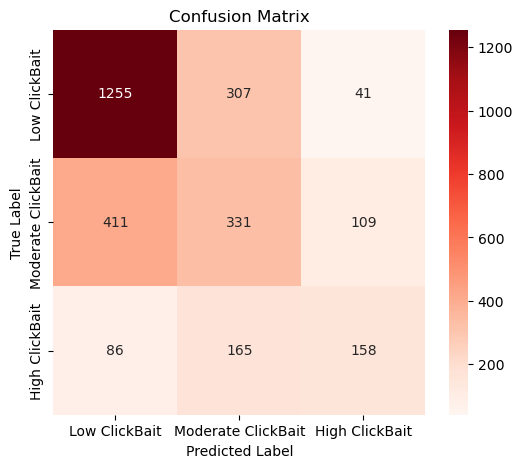

In [39]:
# Generating Confusion Matrix only For Logistic Regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Reds",
            xticklabels=["Low ClickBait","Moderate ClickBait","High ClickBait"],
            yticklabels=["Low ClickBait","Moderate ClickBait","High ClickBait"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

#plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

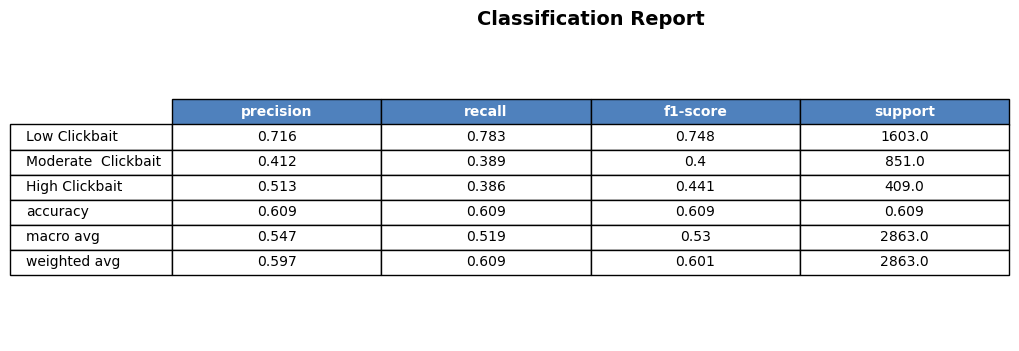

In [40]:
# Generating Classification Report only for Logistic Regression
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Generate classification report
report = classification_report(y_test, y_pred_lr, output_dict=True)
df = pd.DataFrame(report).transpose().round(3)
df.rename(index={
    '0': 'Low Clickbait',
    '1': 'Moderate  Clickbait',
    '2': 'High Clickbait'
}, inplace=True)

# Create figure
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

# Create table
table = ax.table(
    cellText=df.values,
    rowLabels=df.index,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# Font and size
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color only the header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4F81BD")   # Blue header
        cell.set_text_props(color="white", weight="bold")

# Title
plt.title("Classification Report", fontsize=14, fontweight='bold')

# Save image
#plt.savefig("classification_report.png", dpi=300, bbox_inches="tight")

plt.show()

In [42]:
from sklearn.metrics import classification_report
import pandas as pd

f1_results = []

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Support Vector Classifier": svc
}

for name, model in models.items():

    y_pred = model.predict(X_test_tfidf)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    f1_results.append({
        "Model": name,
        "Weighted Precision": report["weighted avg"]["precision"],
        "Weighted Recall": report["weighted avg"]["recall"],
        "Weighted F1-Score": report["weighted avg"]["f1-score"]
    })

metrics_df = pd.DataFrame(f1_results)

# Round all metric columns
metrics_df.iloc[:, 1:] = metrics_df.iloc[:, 1:].round(4)

display(metrics_df)

,Model,Weighted Precision,Weighted Recall,Weighted F1-Score
0,Logistic Regression,0.5969,0.6092,0.6008
1,Naive Bayes,0.5987,0.6235,0.6003
2,Random Forest,0.6063,0.6381,0.6055
3,Support Vector Classifier,0.6162,0.6406,0.6157
